# ggF Offline - Limit Plots

This notebook plots:

- 1D Brazil limit plots which show the observed and expected xsection limits as a function of $m_s$ for a given $m_{\phi}$, T and decay mode.  
- 2D limit plot of the observed excluded mu value as a function of $m_{\phi}$ (x-axis) and T (y-axis). 
- Summary plots: showing the $\mu=1$ exclusion limit for every value of $m_s$ and decay mode.

Using functions in `plot_utils.py`.

Use the Outline to navigate to the desired section.

In [1]:
%config InlineBackend.figure_format = 'retina'
import os
import matplotlib.pyplot as plt
import plot_utils as utils

plt.style.use('physics.mplstyle')

import mplhep as hep
hep.style.use("CMS")

In [8]:
# parameters
itag = '../cards/WH_11_24_combinedEras/'

# outDir = '/home/submit/{}/public_html/SUEP/limits/debug/'.format(os.environ['USER'])
outDirAN = '/home/submit/{}/SUEP/AN-23-183/images/'.format(os.environ['USER'])
# outDirPaper = '/home/submit/{}/SUEP/EXO-23-002/'.format(os.environ['USER'])
# outDirSupp = '/home/submit/{}/SUEP/EXO-23-002/supplementary/'.format(os.environ['USER'])

saveToAN = True
saveToPaper = False

# if not os.path.isdir(outDir): os.mkdir(outDir)

## 2D Limits: $m_{\phi}$, T scan

In [3]:
import numpy as np
from matplotlib import ticker
import matplotlib.tri as tri
import pandas as pd
import math

def plot_mphi_by_T_limits(
        temp_by_mphi, ms, decay, 
        path='../', verbose=False, method='AsymptoticLimits', analysis='wh', 
        fig=None, ax=None, obs_marker='o', exp_alpha=1.0,mu_limit=False):
    """
    Make 1D Brazil plot for some choice of mPhi, temp, and decay, scanning over mS.
    """
    
    limits = utils.get_scan_limits(path=path, ms=ms, decay=decay, method=method, analysis=analysis, return_xsec=not mu_limit)
    temp_over_mphi = np.array([l[0][2]/l[0][1] for l in limits])  
    limits = [l for l, tom in zip(limits, temp_over_mphi) if tom == temp_by_mphi]

    mphi = np.array([l[0][1] for l in limits])
    temp = np.array([l[0][2] for l in limits])
    xsec = np.array([l[0][4] for l in limits])
    if mu_limit: xsec = np.array([1]*len(limits))

    _exp = np.array([l[1][1][2] for l in limits])
    _s1p = np.array([l[1][1][1] for l in limits]) 
    _s1m = np.array([l[1][1][3] for l in limits]) 
    _s2p = np.array([l[1][1][0] for l in limits]) 
    _s2m = np.array([l[1][1][4] for l in limits]) 
    _obs = np.array([l[1][1][5] for l in limits]) 
        
    # Define interpolation
    exp_limit = utils.log_interp1d(temp, _exp) 
    s1p_limit = utils.log_interp1d(temp, _s1p)
    s1m_limit = utils.log_interp1d(temp, _s1m)
    s2p_limit = utils.log_interp1d(temp, _s2p)
    s2m_limit = utils.log_interp1d(temp, _s2m)
    obs_limit = utils.log_interp1d(temp, _obs)
    th_limit =  utils.log_interp1d(temp, xsec)

    # Make 1D limit plot
    if ax is None:
        fig = plt.figure(figsize=(10,10))
        ax = fig.subplots()
        
    T_min = 2*utils.mA[decay]*temp_by_mphi # kinematic constraint
    xvar = np.linspace(T_min, max(temp)+2, 1000)

    # plot theory
    ax.plot(xvar, th_limit(xvar), "--", ms=12, color='blue', label="$\sigma_{theory}$")
    
    #Plot expected limits including brazil bands
    ax.plot(xvar, exp_limit(xvar), ls="--", ms=12, color='black', label="Median expected")
    ax.fill_between(xvar, s2m_limit(xvar), s2p_limit(xvar), color="#FFCC01", alpha=exp_alpha, lw=0, label="Expected 95% CL")
    ax.fill_between(xvar, s1m_limit(xvar), s1p_limit(xvar), color="#00CC00", alpha=exp_alpha, lw=0, label="Expected 68% CL")

    # Plot observed limits
    ax.scatter(temp, _obs, marker=obs_marker, s=70, color='black', label="Observed") 
    
    # Just to make everything look nice
    ax.plot([T_min]*50, np.linspace(1e-4,1e7,50),color='black', linestyle='--', alpha =0.5)
    ax.text(
        T_min-0.15, 5e-2, r"$T_{D}<2m_{A^'} \times "+"{:.2f}$".format(temp_by_mphi),
        horizontalalignment='right', verticalalignment='center',fontsize=20,rotation=-90
    )
    if mu_limit:
        ax.set_ylabel(r"$\mu \equiv \sigma_{\mathrm{obs.}}/\sigma_{\mathrm{theory}}$")
    else:
        ax.set_ylabel(r"$\sigma$ (pb)")
    ax.set_xlabel(r"$T_D$ [GeV]") 
    ax.legend(loc="upper left", fontsize=20)
    _ = ax.text(
        0.65, 0.82, "$T_D/m_{{\phi}}$ = {}""\n""{}".format(temp_by_mphi,utils.decaysLabelsWithLineBreaks[decay]),
        fontsize=20, horizontalalignment='left', 
        verticalalignment='bottom', 
        transform=ax.transAxes,
    )
    ax.grid(visible=True, which='major', color='grey', linestyle='--', alpha=0.3)
    ax.set_ylim(1e-4, 1e7)
    ax.set_xlim(0)
    ax.set_yscale("log")
    y_major = ticker.LogLocator(base = 10.0, numticks = 20)
    ax.yaxis.set_major_locator(y_major)
    y_minor = ticker.LogLocator(base = 10.0, subs = np.arange(1.0, 10.0) * 0.1, numticks = 100)
    ax.yaxis.set_minor_locator(y_minor)
    ax.yaxis.set_minor_formatter(ticker.NullFormatter())

    if fig is not None:
        fig.tight_layout()
        fig.set_label("limits1D_mphi_by_T_{:.2f}_{}".format(temp_by_mphi, decay))
        return fig
    else:
        return ax


In [4]:
import numpy as np
zh = np.loadtxt("SRCR_generic_limAsy.txt", delimiter=":")
norm = 0.909
obs = zh[:,-1]
mPhi = zh[:,1]
T = zh[:,2]
s2m = zh[:, 3]
s1m = zh[:, 4]
exp = zh[:, 5]
s1p = zh[:, 6]
s2p = zh[:, 7]

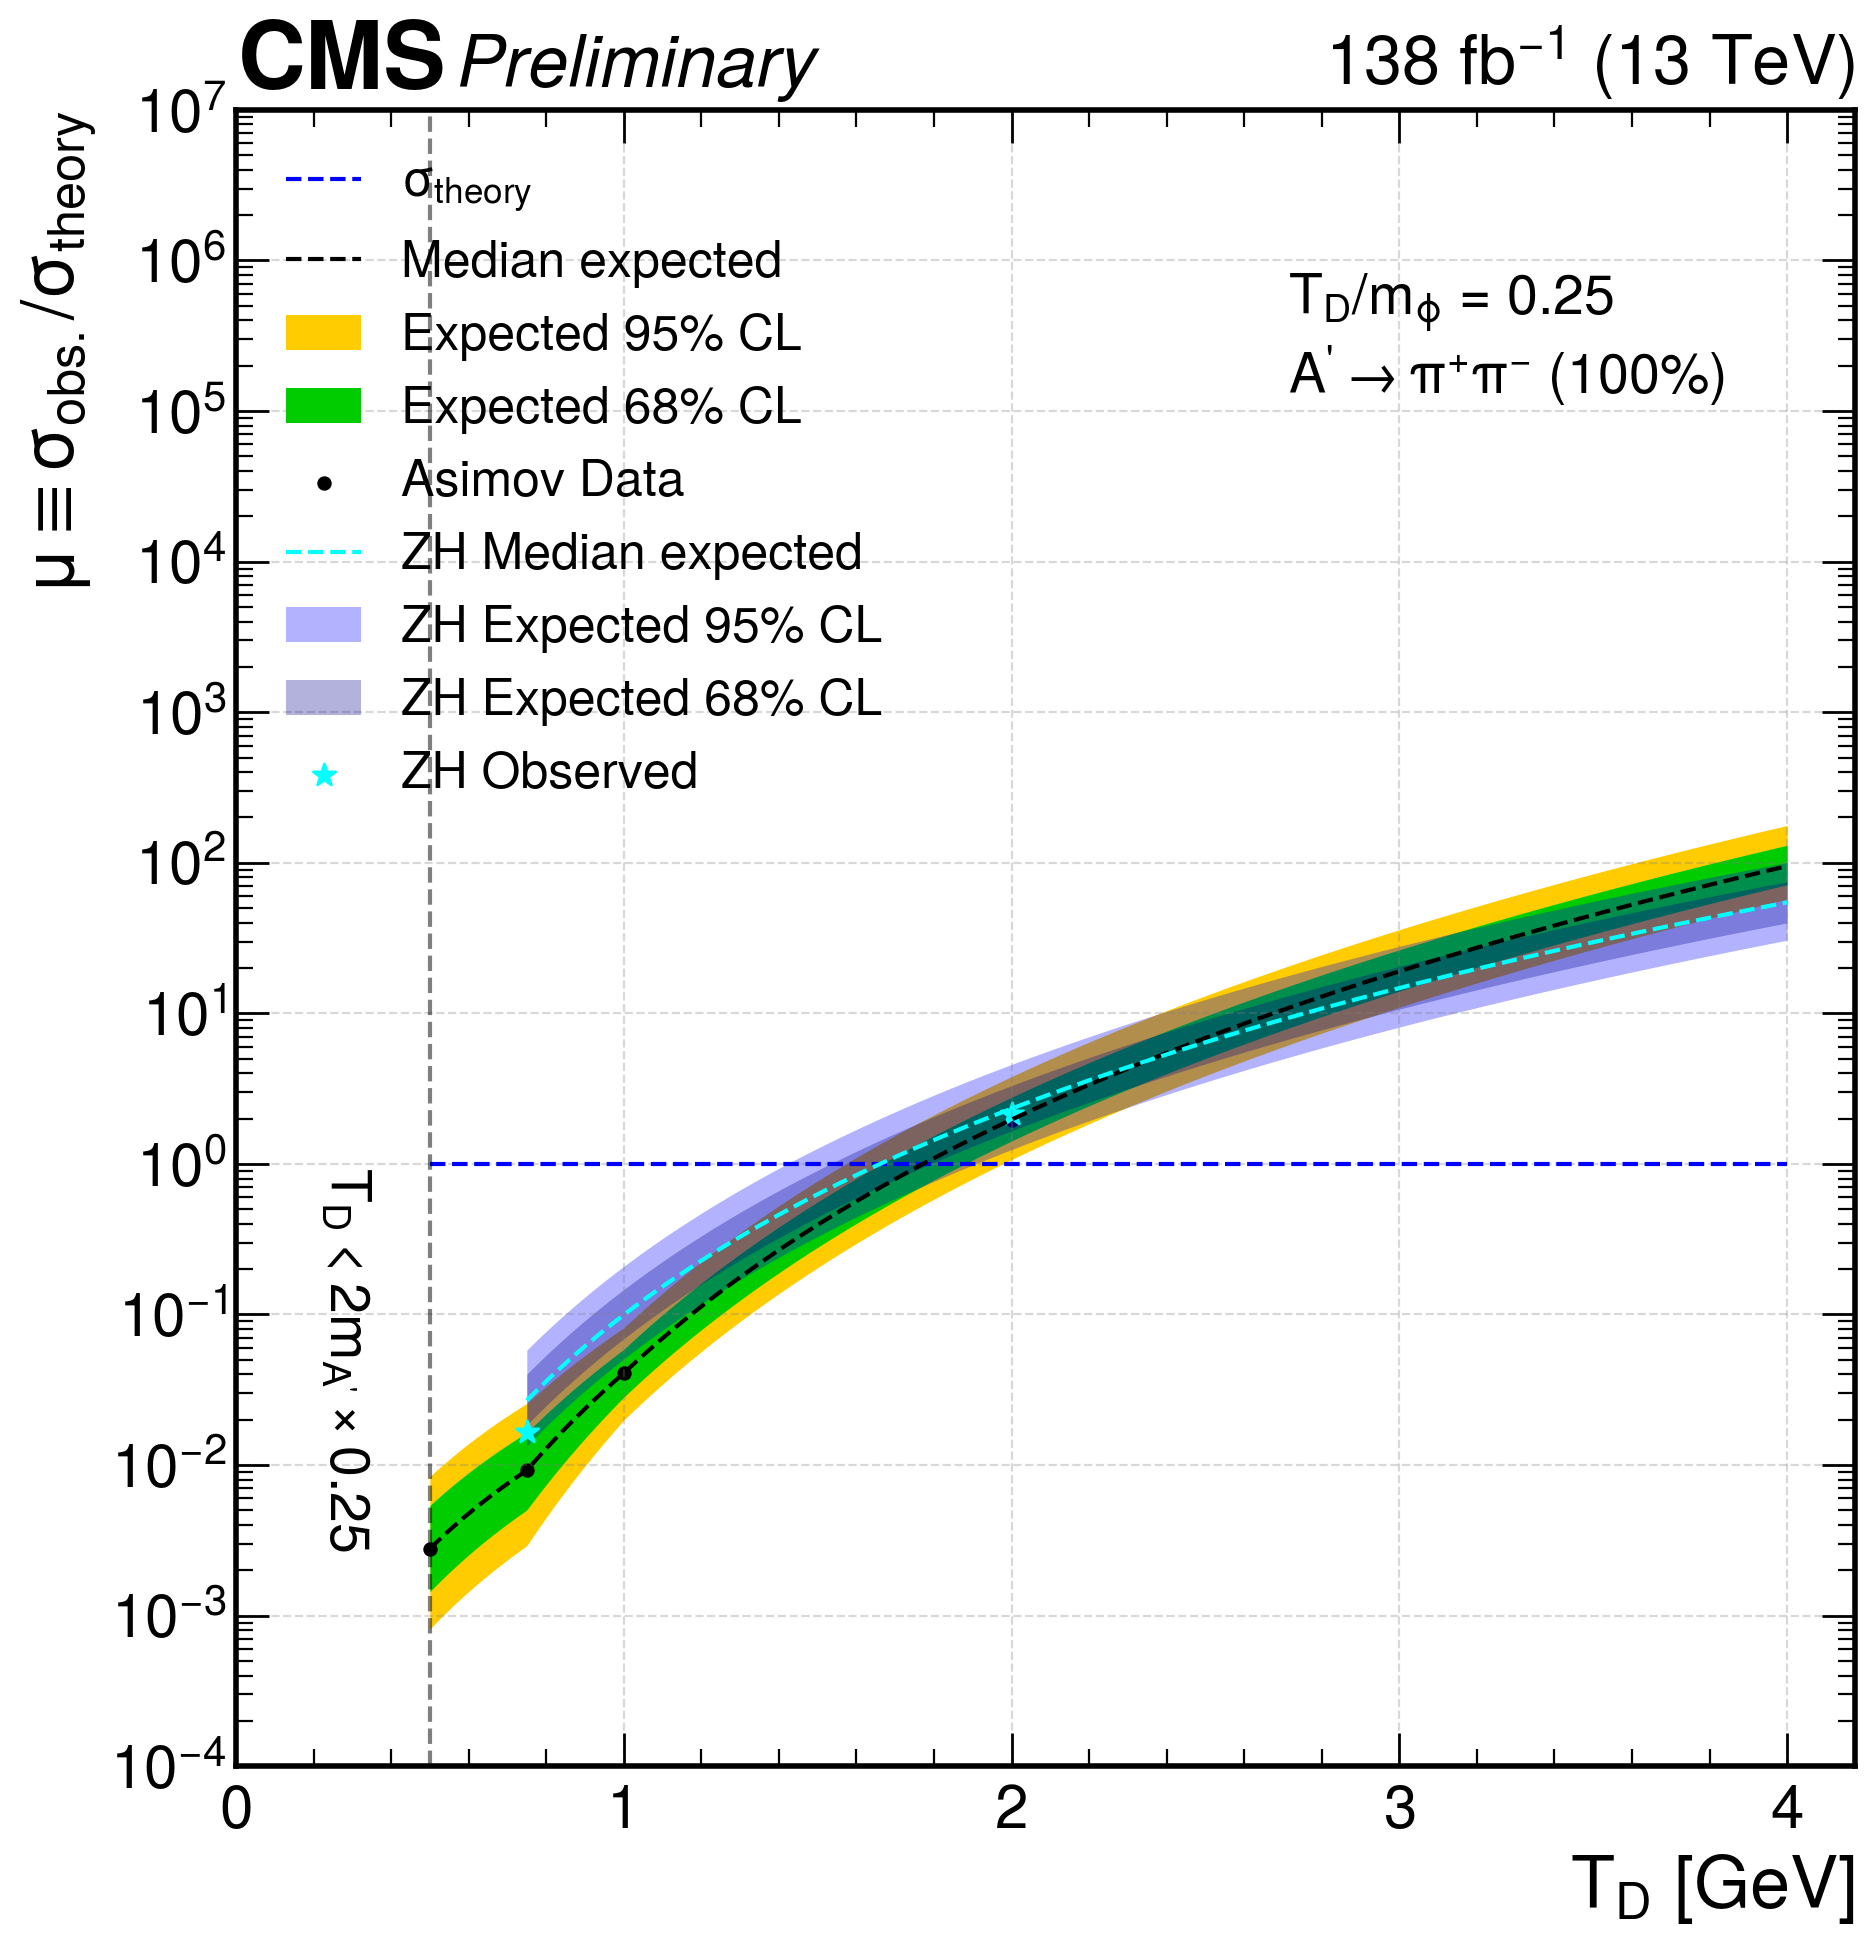

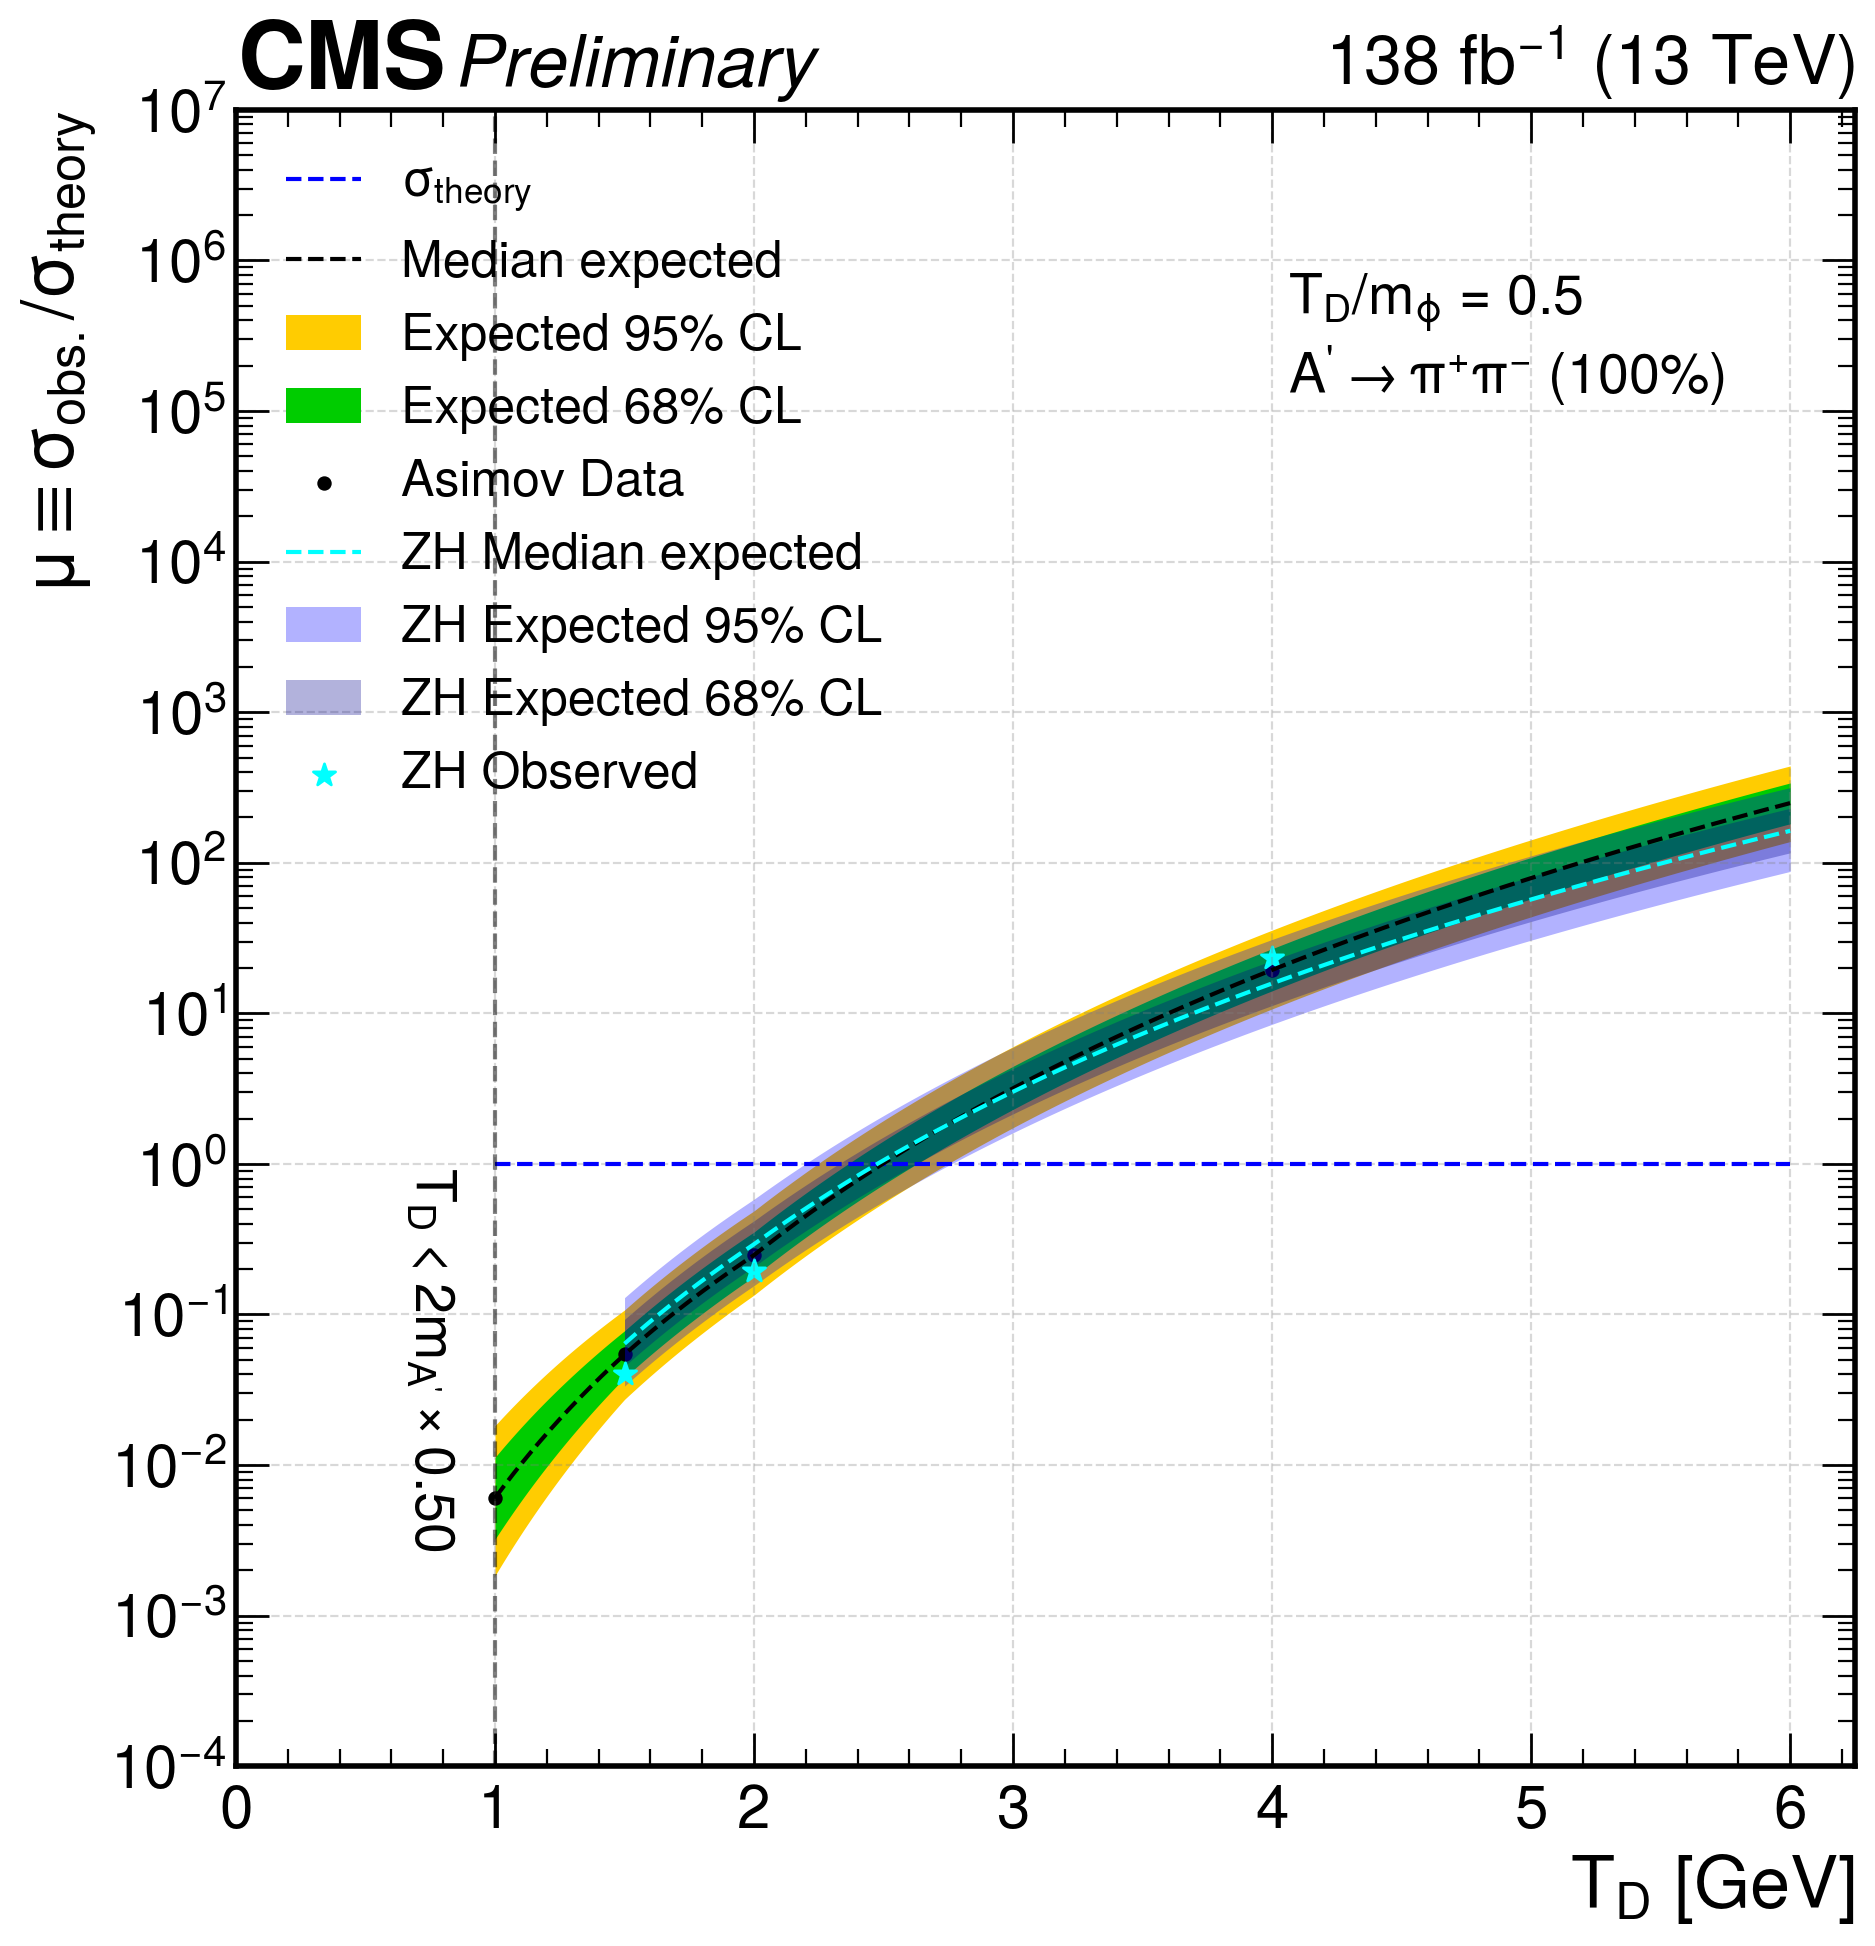

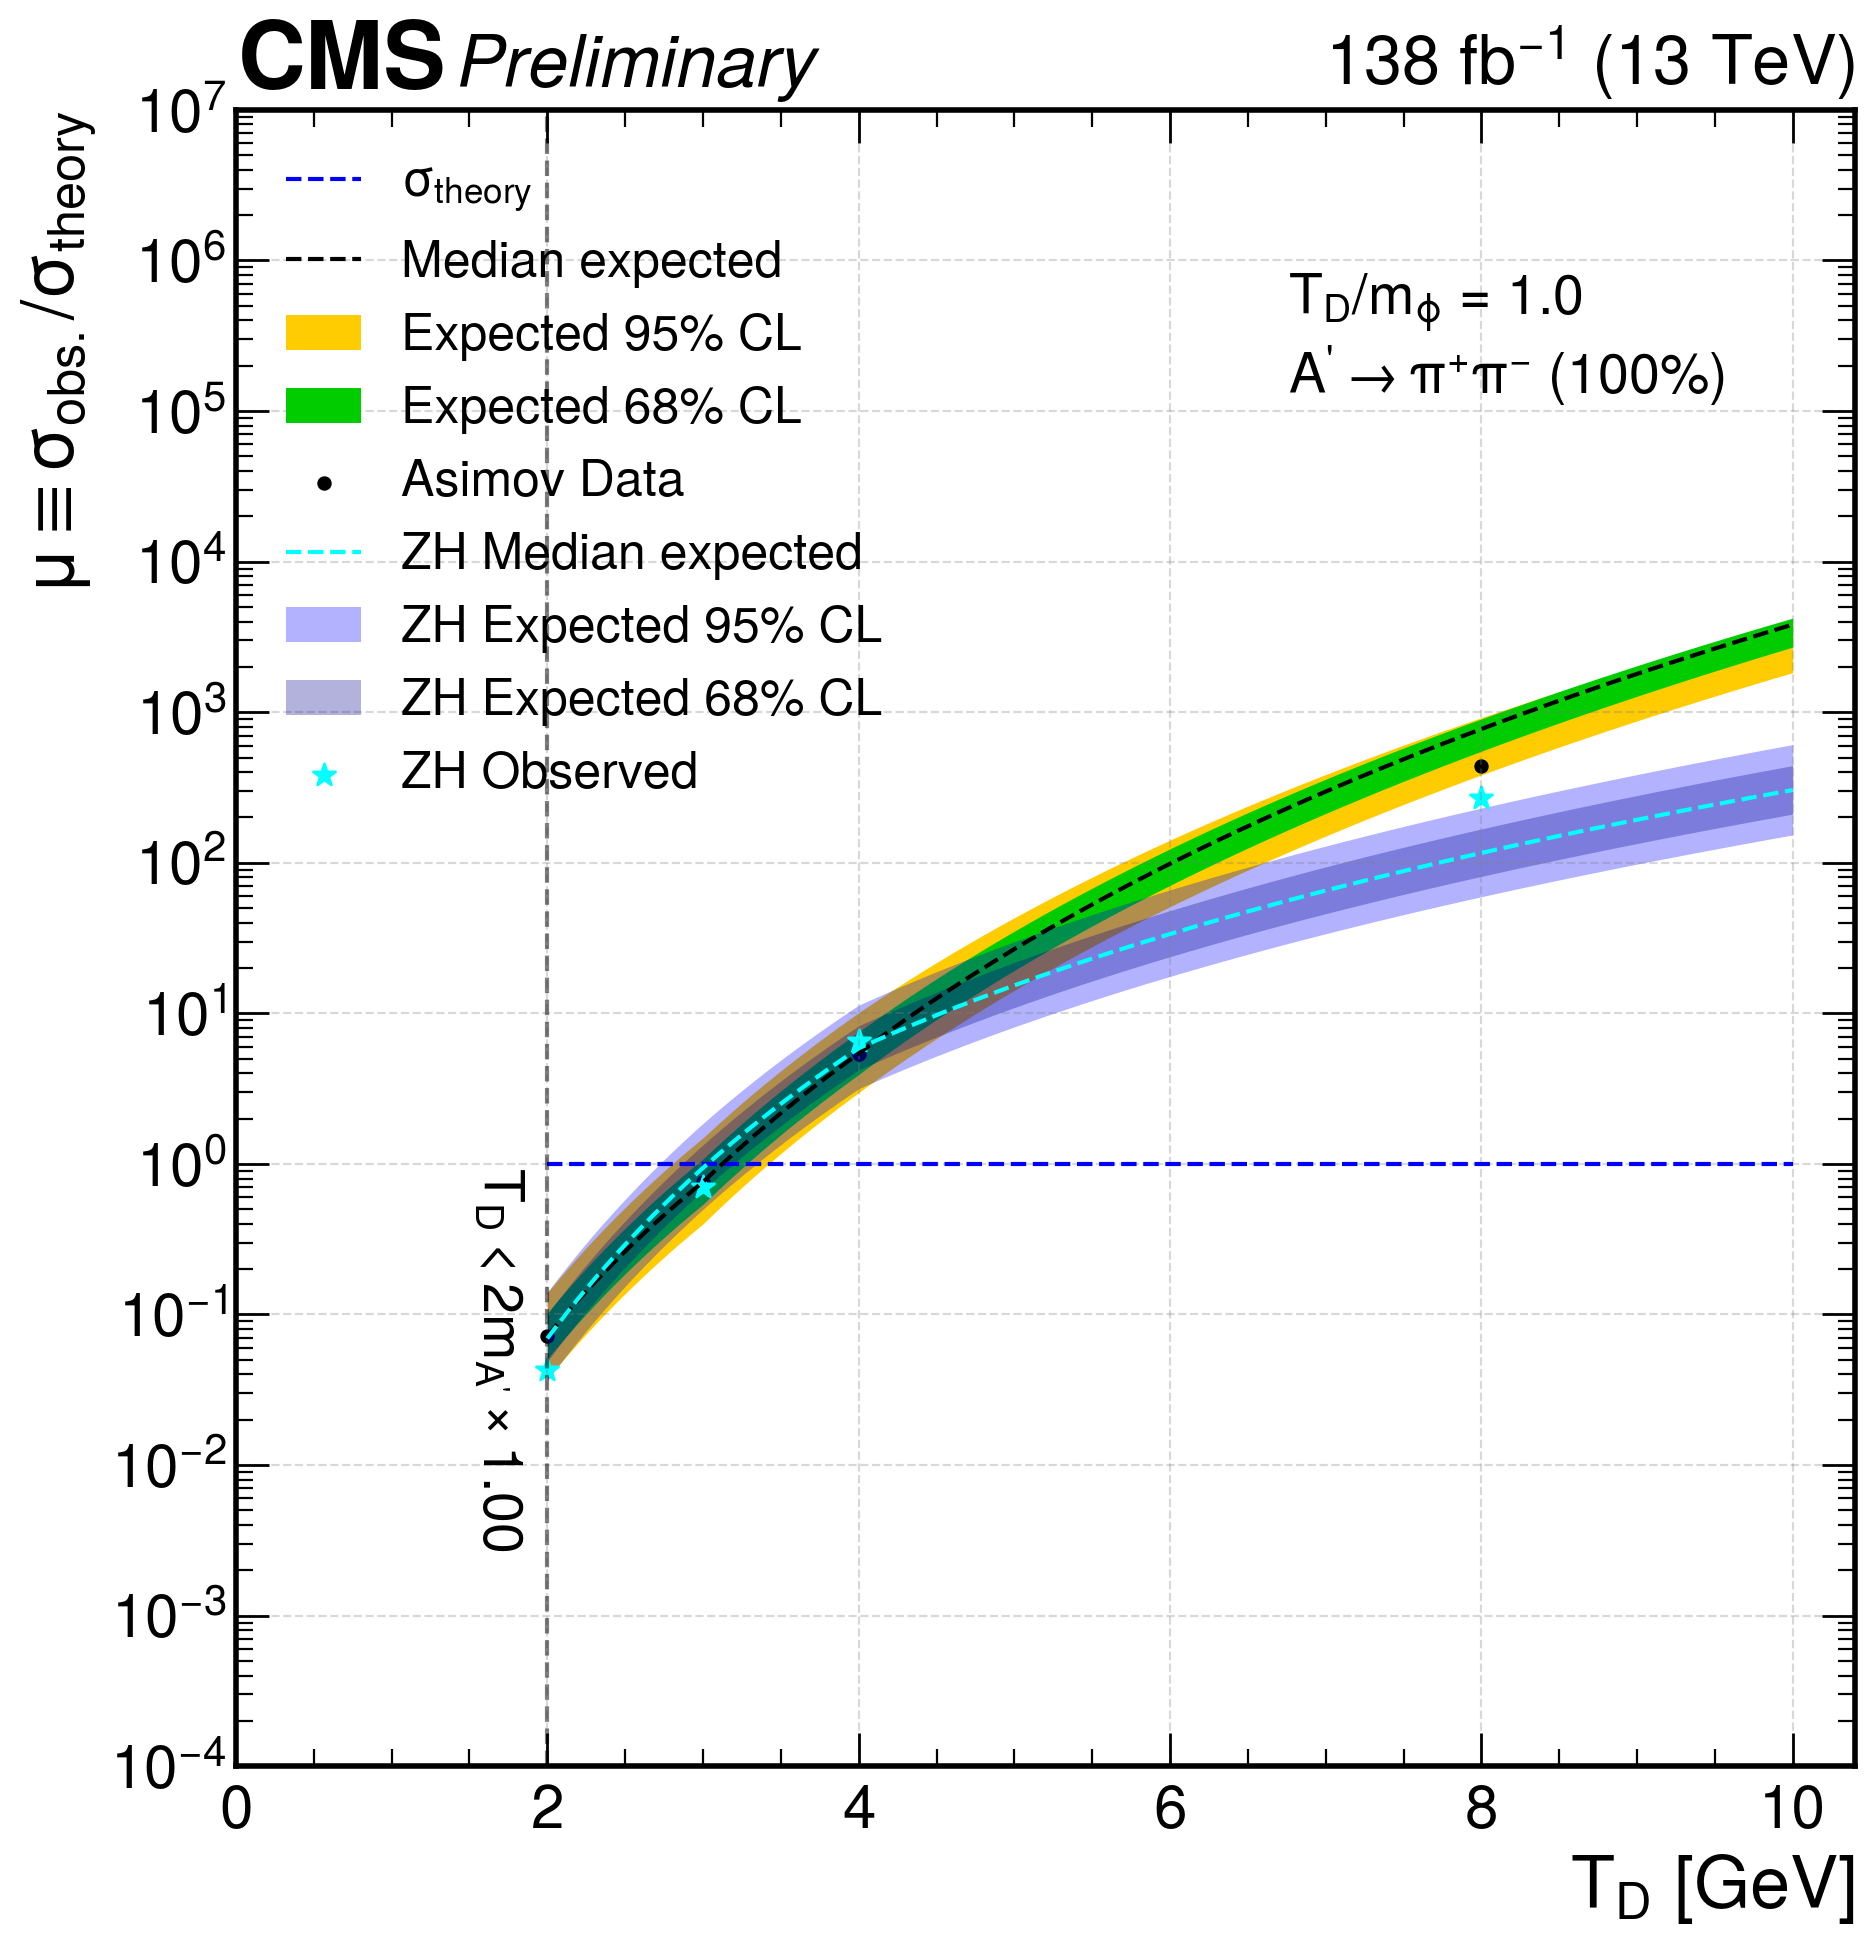

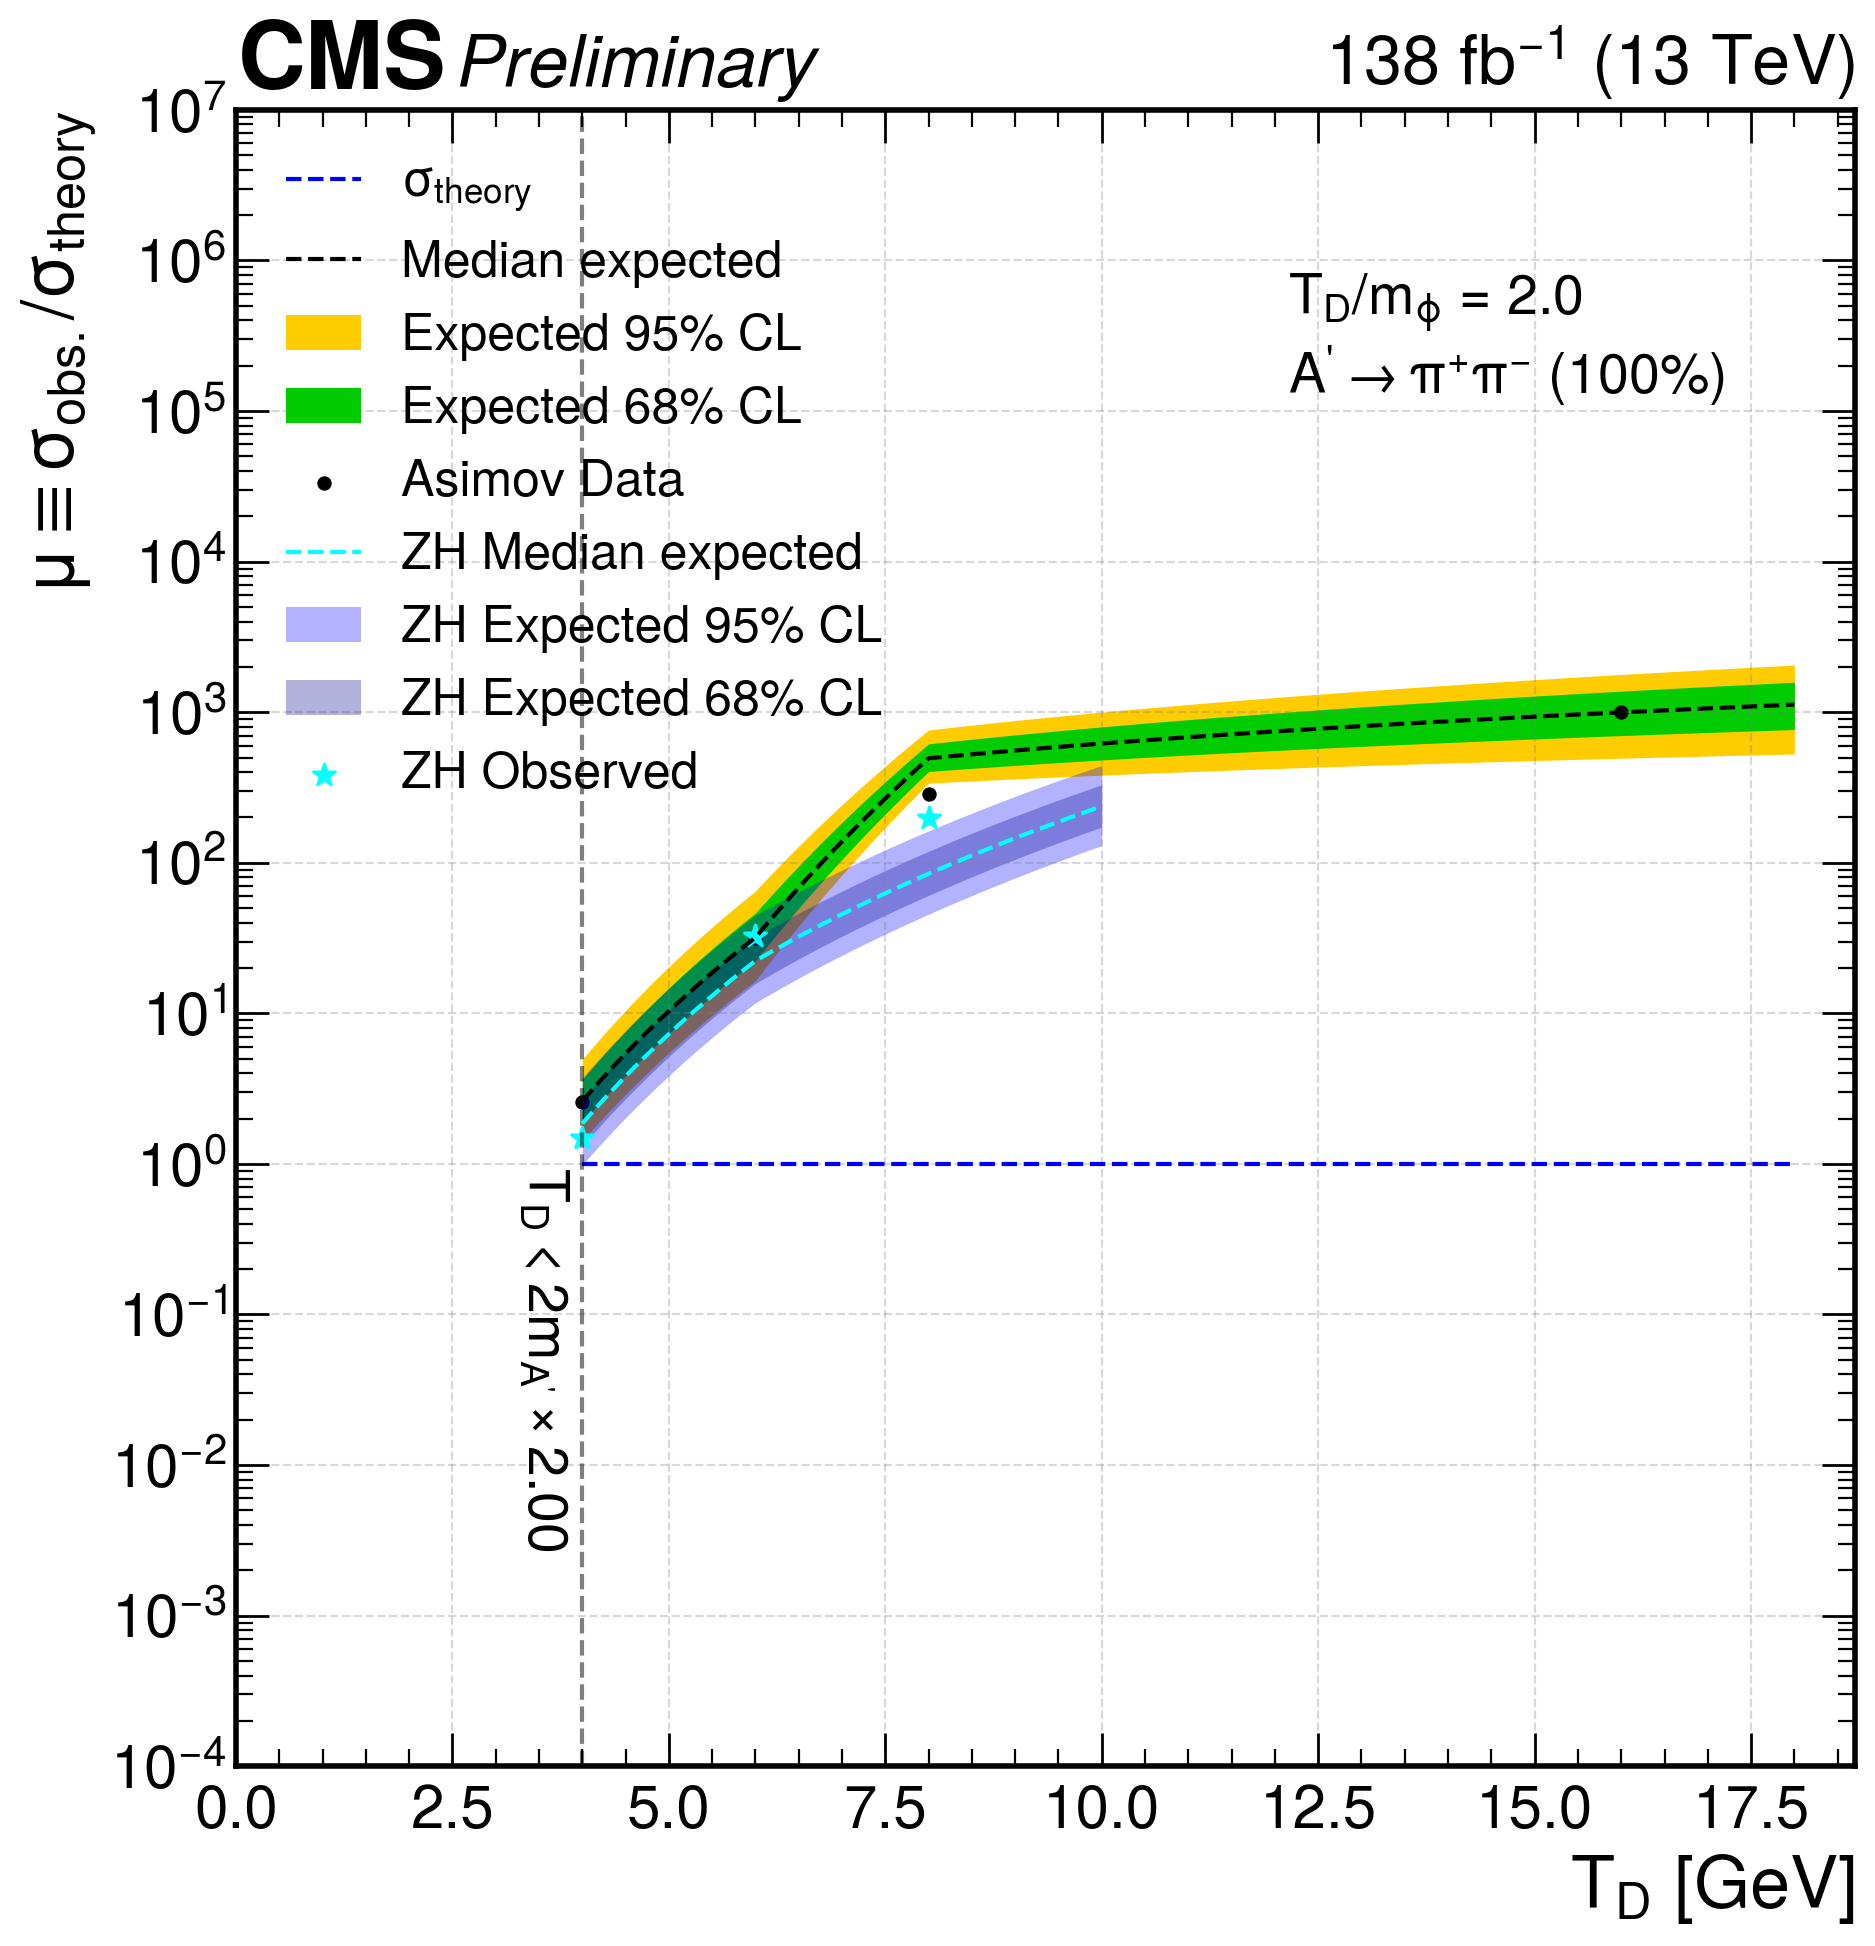

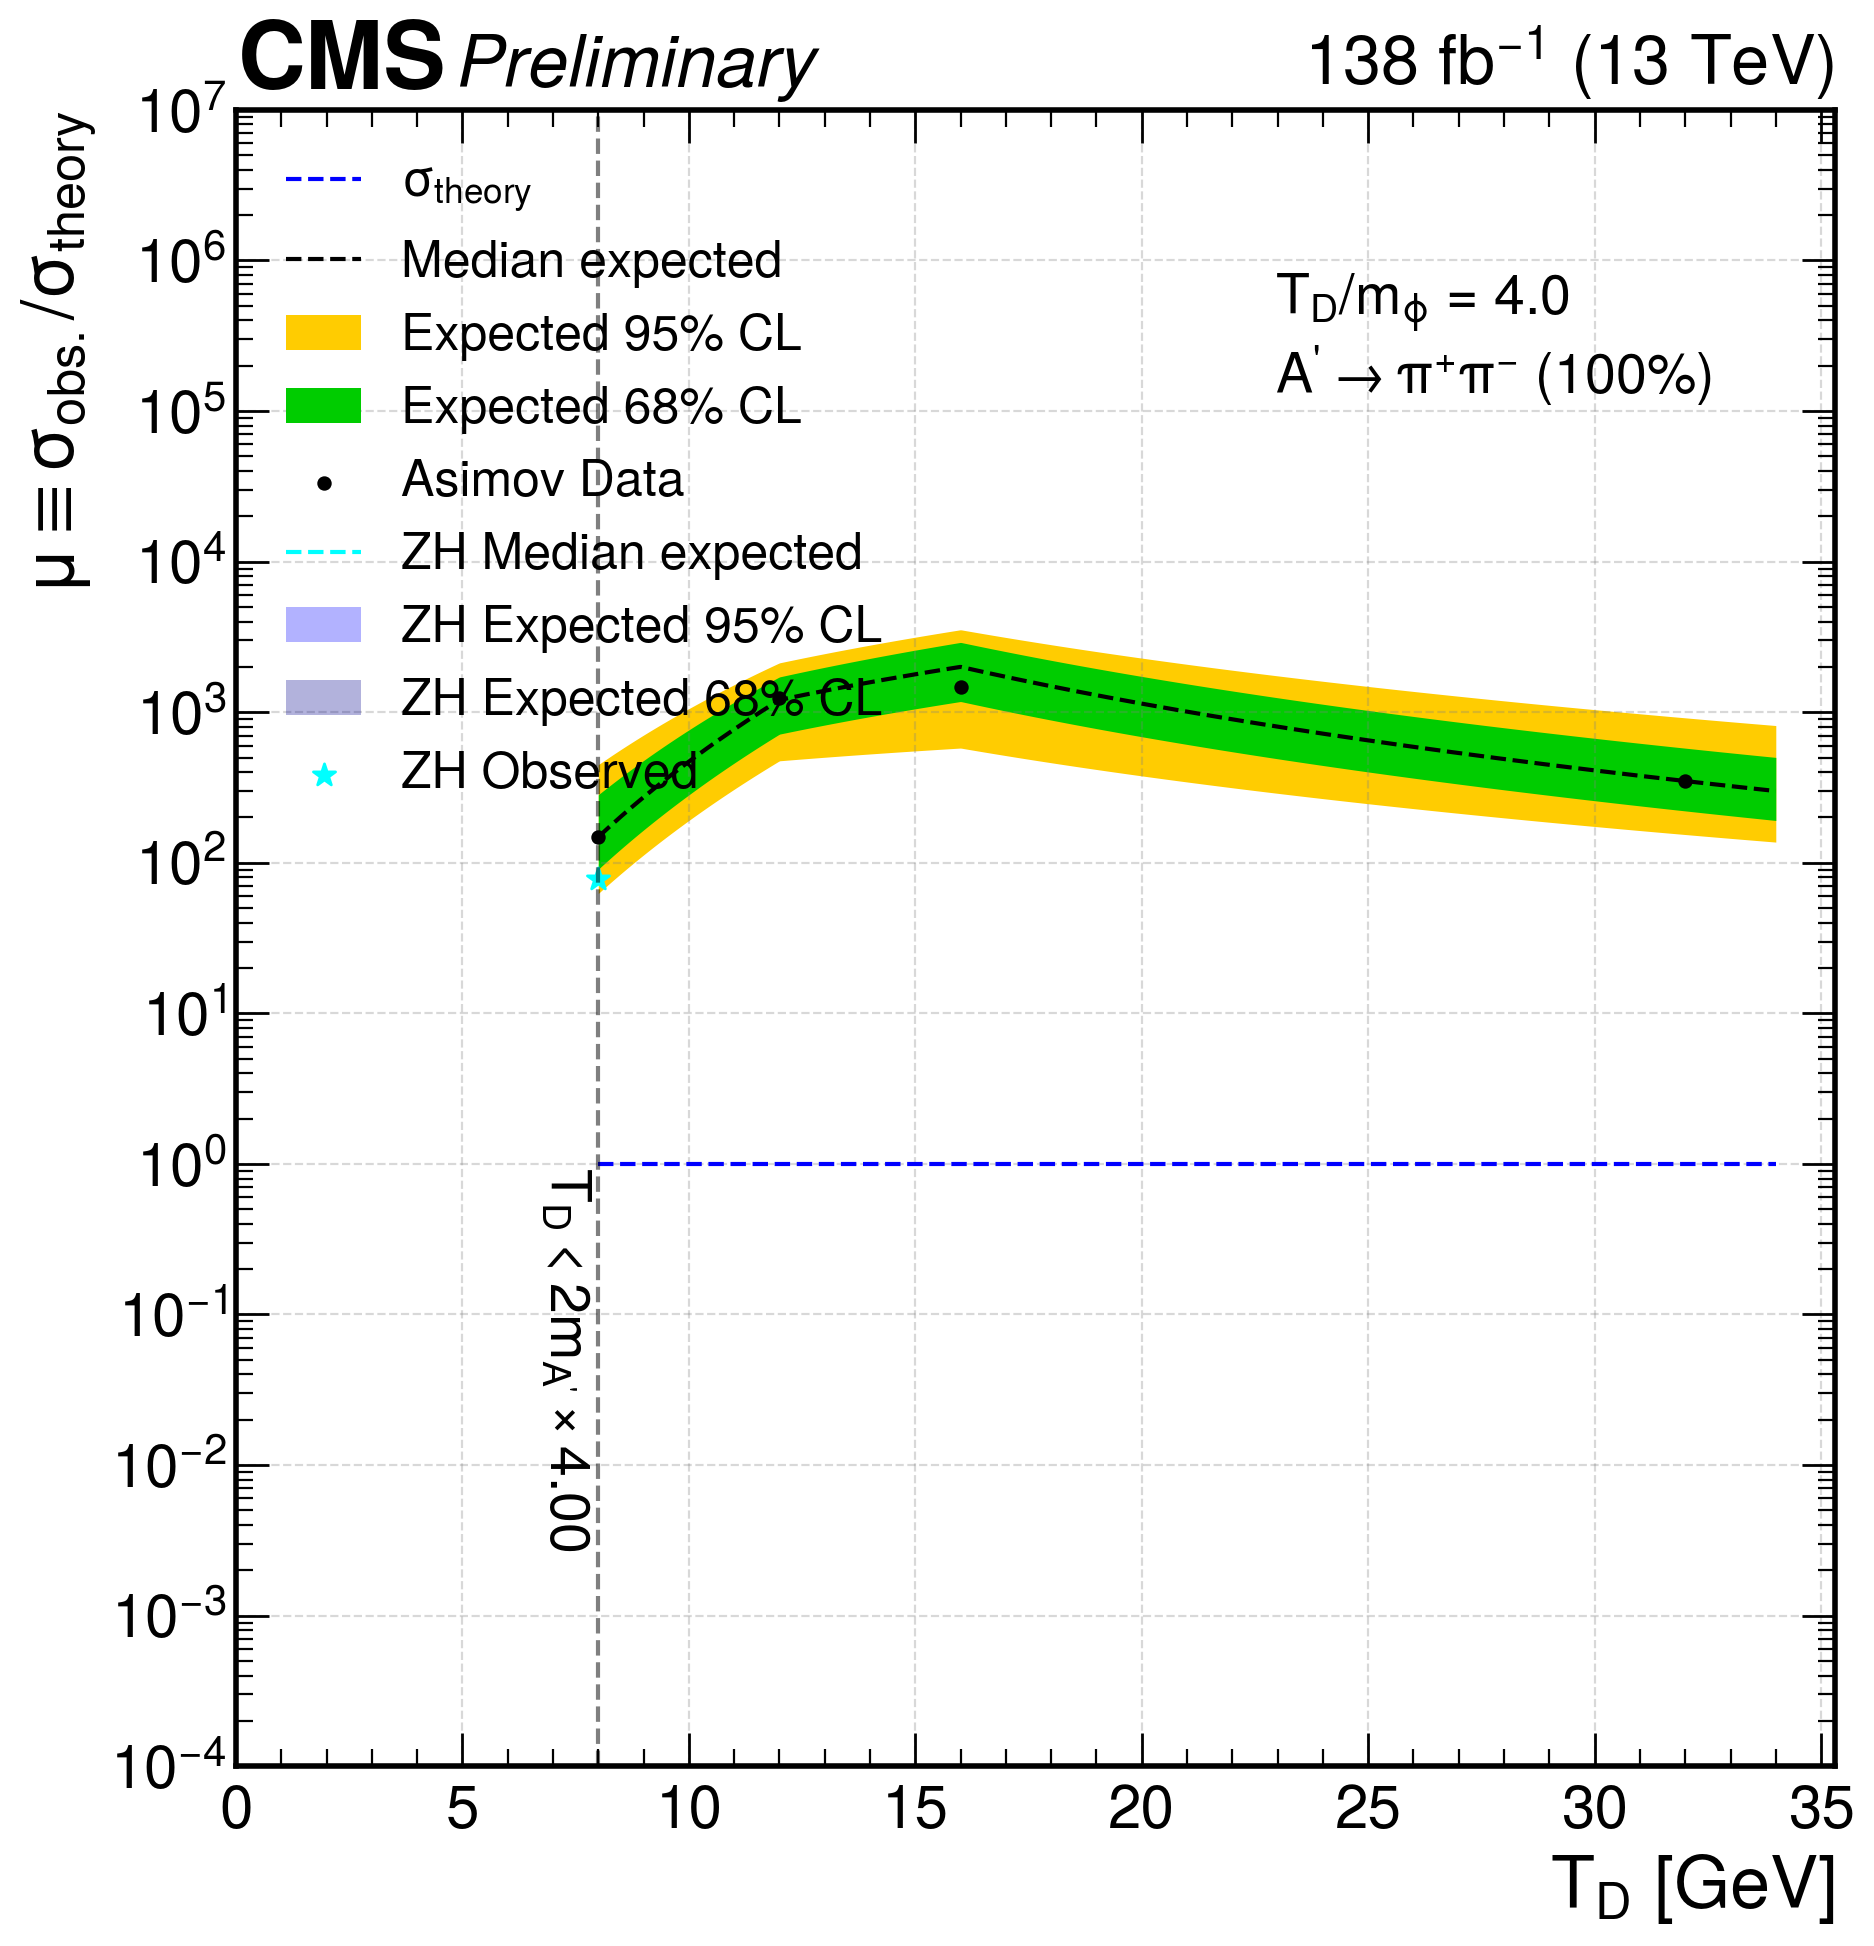

In [15]:
mphi_by_t = [0.25, 0.5, 1.0, 2.0, 4.0]
show_zh = True

for i in mphi_by_t:
    fig = plot_mphi_by_T_limits(temp_by_mphi=i, ms=125, decay='generic', path=itag, obs_marker='.', method='AsymptoticLimits', analysis='wh', mu_limit=True)
    hep.cms.label(data=True, llabel='Preliminary', lumi=utils.lumis['combined'], ax=fig.get_axes()[0])

    # code for adding the ZH limits to this plot
    if show_zh:
        mask = (T/mPhi == i) & (T < 10) & ((T != 0.5) & (mPhi != 0.5) & (T != 1.0) & (mPhi != 1.0))

        xvar = np.linspace(min(T[mask]), max(T[mask])+2, 1000)
        exp_limit = utils.log_interp1d(T[mask], exp[mask]) 
        s1p_limit = utils.log_interp1d(T[mask], s1p[mask])
        s1m_limit = utils.log_interp1d(T[mask], s1m[mask])
        s2p_limit = utils.log_interp1d(T[mask], s2p[mask])
        s2m_limit = utils.log_interp1d(T[mask], s2m[mask])

        ax = fig.get_axes()[0]
        ax.plot(xvar, exp_limit(xvar), ls="--", ms=12, color='cyan', label="ZH Median expected")
        ax.fill_between(xvar, s2m_limit(xvar), s2p_limit(xvar), color="blue", alpha=0.3, lw=0, label="ZH Expected 95% CL")
        ax.fill_between(xvar, s1m_limit(xvar), s1p_limit(xvar), color="darkblue", alpha=0.3, lw=0, label="ZH Expected 68% CL")
        ax.scatter(T[mask], obs[mask], marker='*', s=70, color='cyan', label="ZH Observed") 

    # temporary: while blinded, we are using Asimov data for observed
    handles, labels = fig.get_axes()[0].get_legend_handles_labels()
    for i in range(len(labels)):
        if labels[i] == "Observed": labels[i] = "Asimov Data"
    fig.get_axes()[0].legend(handles, labels, loc="upper left", fontsize='x-small')

    if saveToAN:
        fig.savefig(outDirAN + fig.get_label() + '.pdf', bbox_inches='tight')

not found: 'limit' (with any cycle number)

    Available keys: 'toys;1'

in file ../cards/WH_11_20_fixed_noShape/higgsCombineSUEP_mS125.000_mPhi2.000_T8.000_modegeneric.AsymptoticLimits.mH125.root
File doesn't exist ../cards/WH_11_20_fixed_noShape/higgsCombineSUEP_mS125.000_mPhi2.000_T8.000_modegeneric.AsymptoticLimits.mH125.root


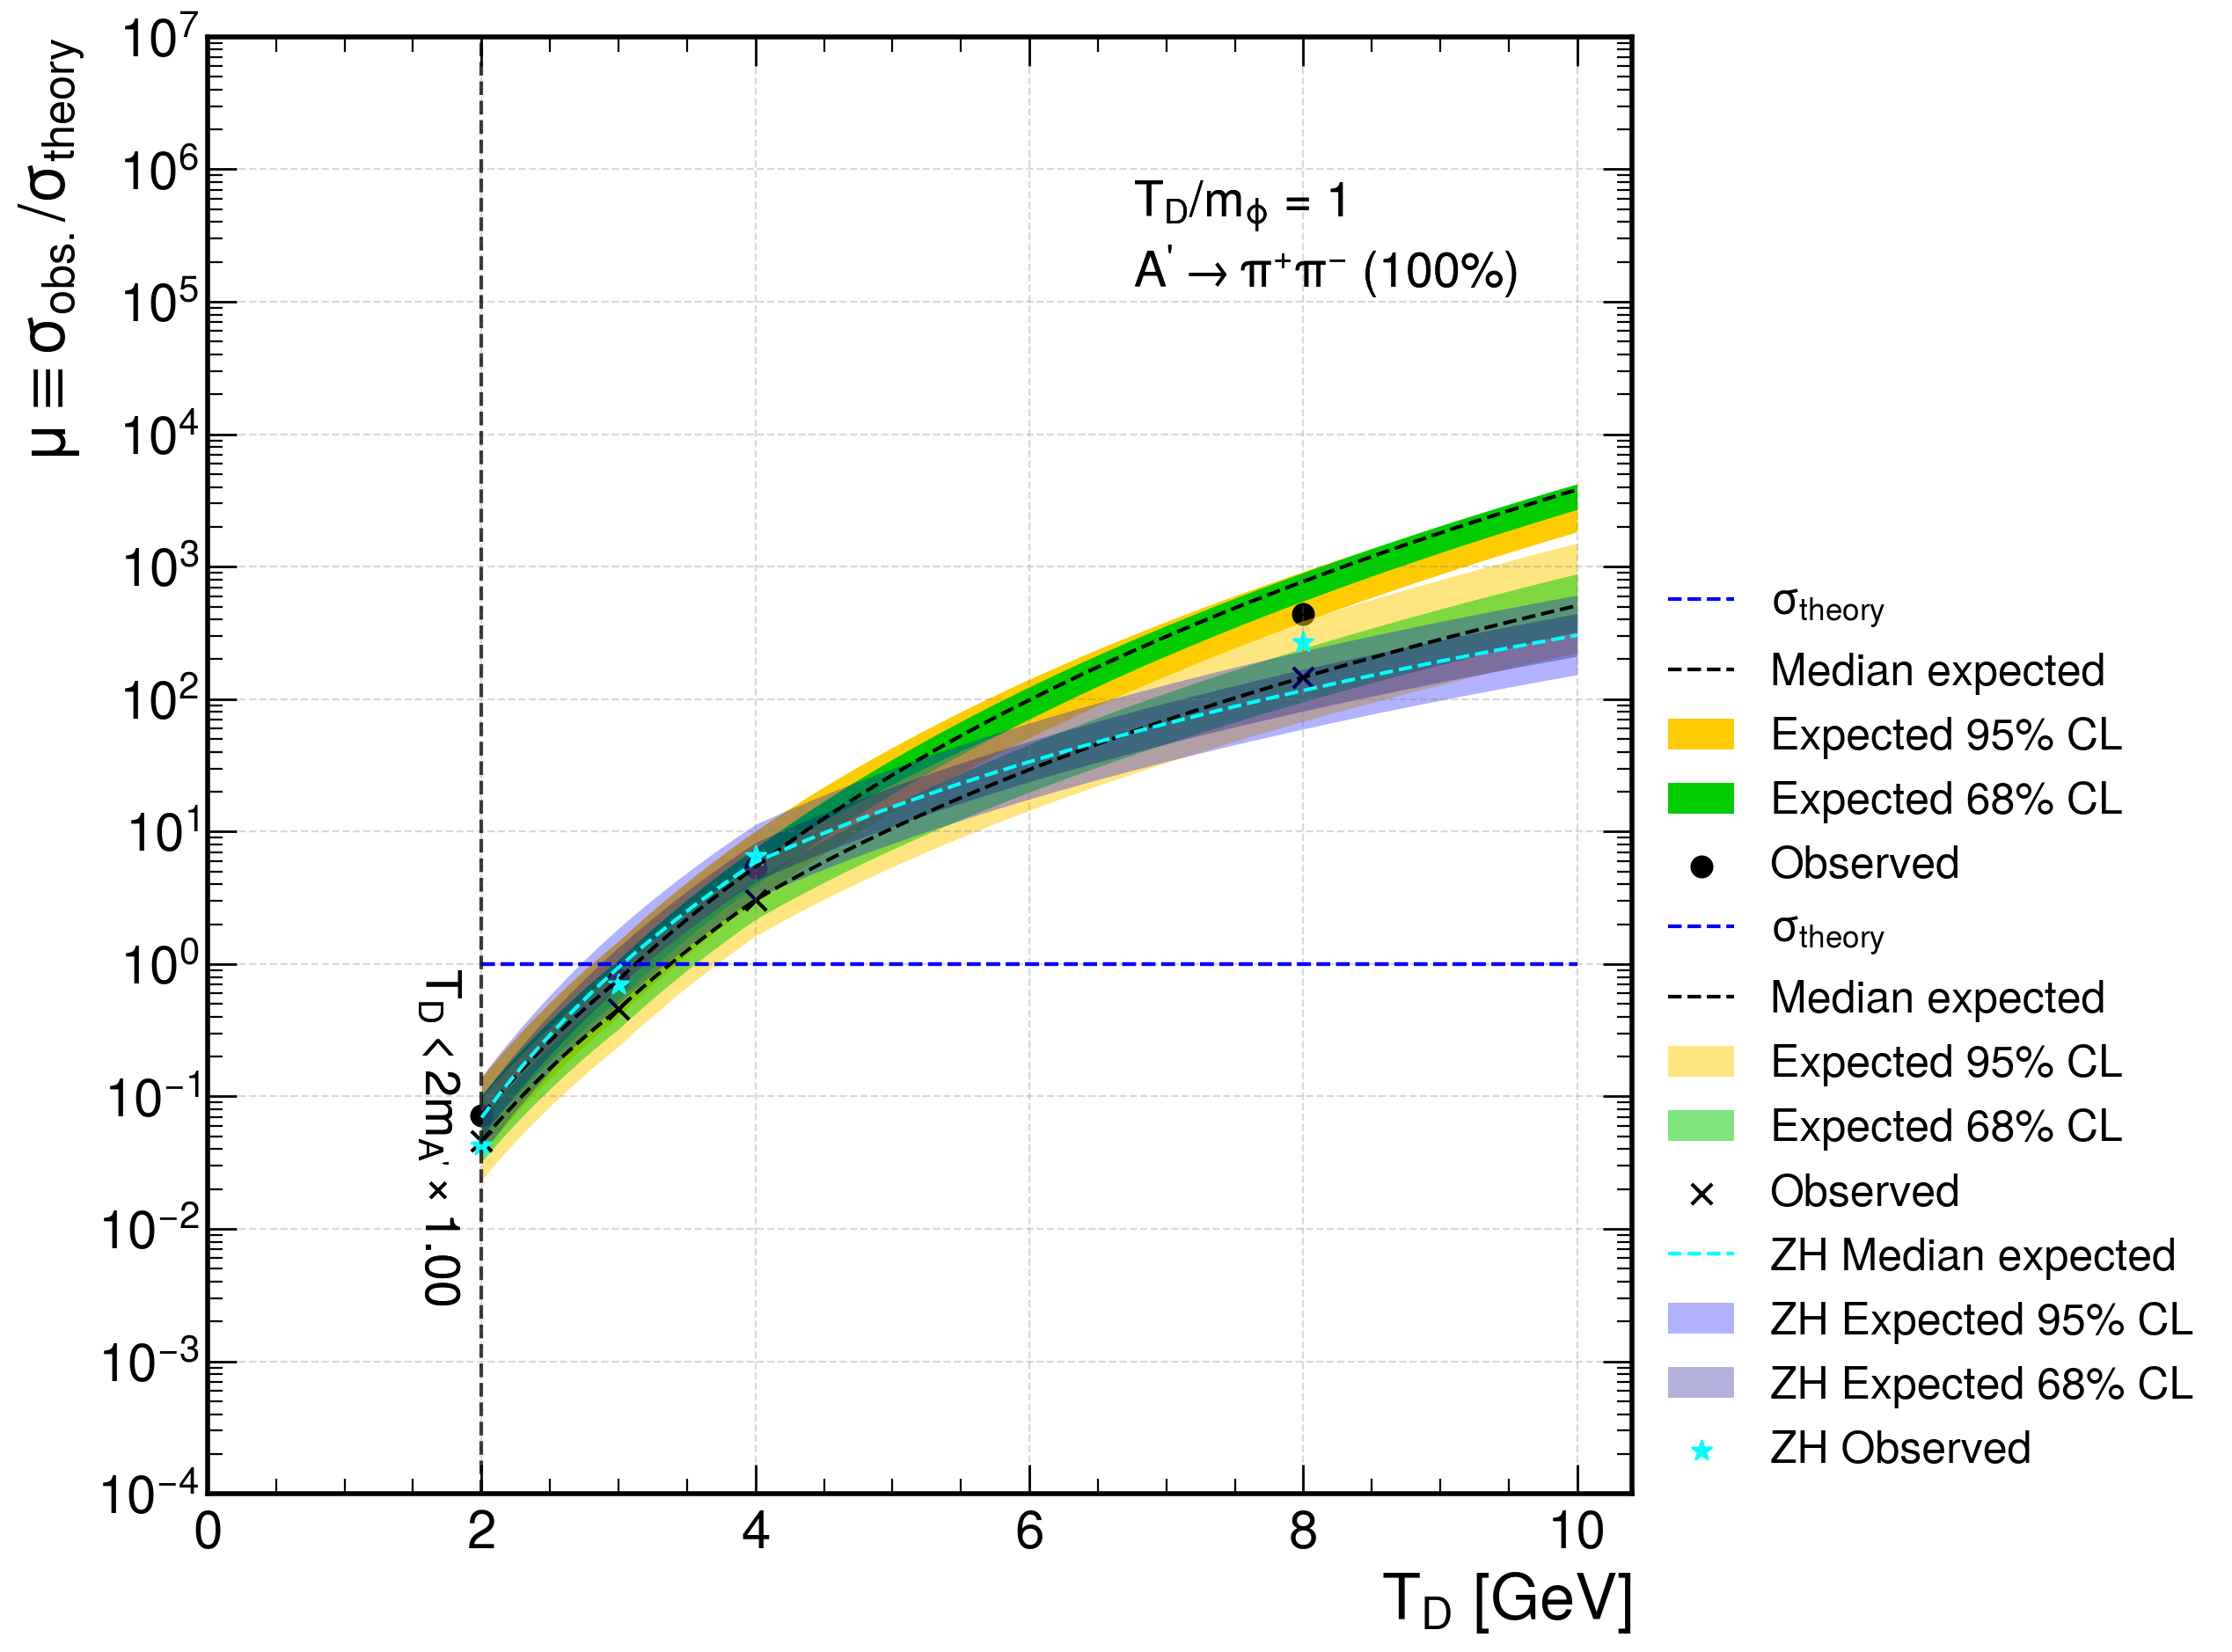

In [6]:
fig = plot_mphi_by_T_limits(temp_by_mphi=1, ms=125, decay='generic', path=itag, obs_marker='o', method='AsymptoticLimits', analysis='wh', mu_limit=True)
fig2 = plot_mphi_by_T_limits(temp_by_mphi=1, ms=125, decay='generic', path='../cards/WH_11_20_fixed_noShape/', obs_marker='x', exp_alpha=0.5, method='AsymptoticLimits', analysis='wh', mu_limit=True, ax=fig.get_axes()[0])

mask = (T/mPhi == 1) & (T < 10)

xvar = np.linspace(min(T[mask]), max(T[mask])+2, 1000)
exp_limit = utils.log_interp1d(T[mask], exp[mask]) 
s1p_limit = utils.log_interp1d(T[mask], s1p[mask])
s1m_limit = utils.log_interp1d(T[mask], s1m[mask])
s2p_limit = utils.log_interp1d(T[mask], s2p[mask])
s2m_limit = utils.log_interp1d(T[mask], s2m[mask])

ax = fig.get_axes()[0]
ax.plot(xvar, exp_limit(xvar), ls="--", ms=12, color='cyan', label="ZH Median expected")
ax.fill_between(xvar, s2m_limit(xvar), s2p_limit(xvar), color="blue", alpha=0.3, lw=0, label="ZH Expected 95% CL")
ax.fill_between(xvar, s1m_limit(xvar), s1p_limit(xvar), color="darkblue", alpha=0.3, lw=0, label="ZH Expected 68% CL")
ax.scatter(T[mask], obs[mask], marker='*', s=70, color='cyan', label="ZH Observed") 
ax.legend(loc=(1.01, 0), fontsize='x-small')

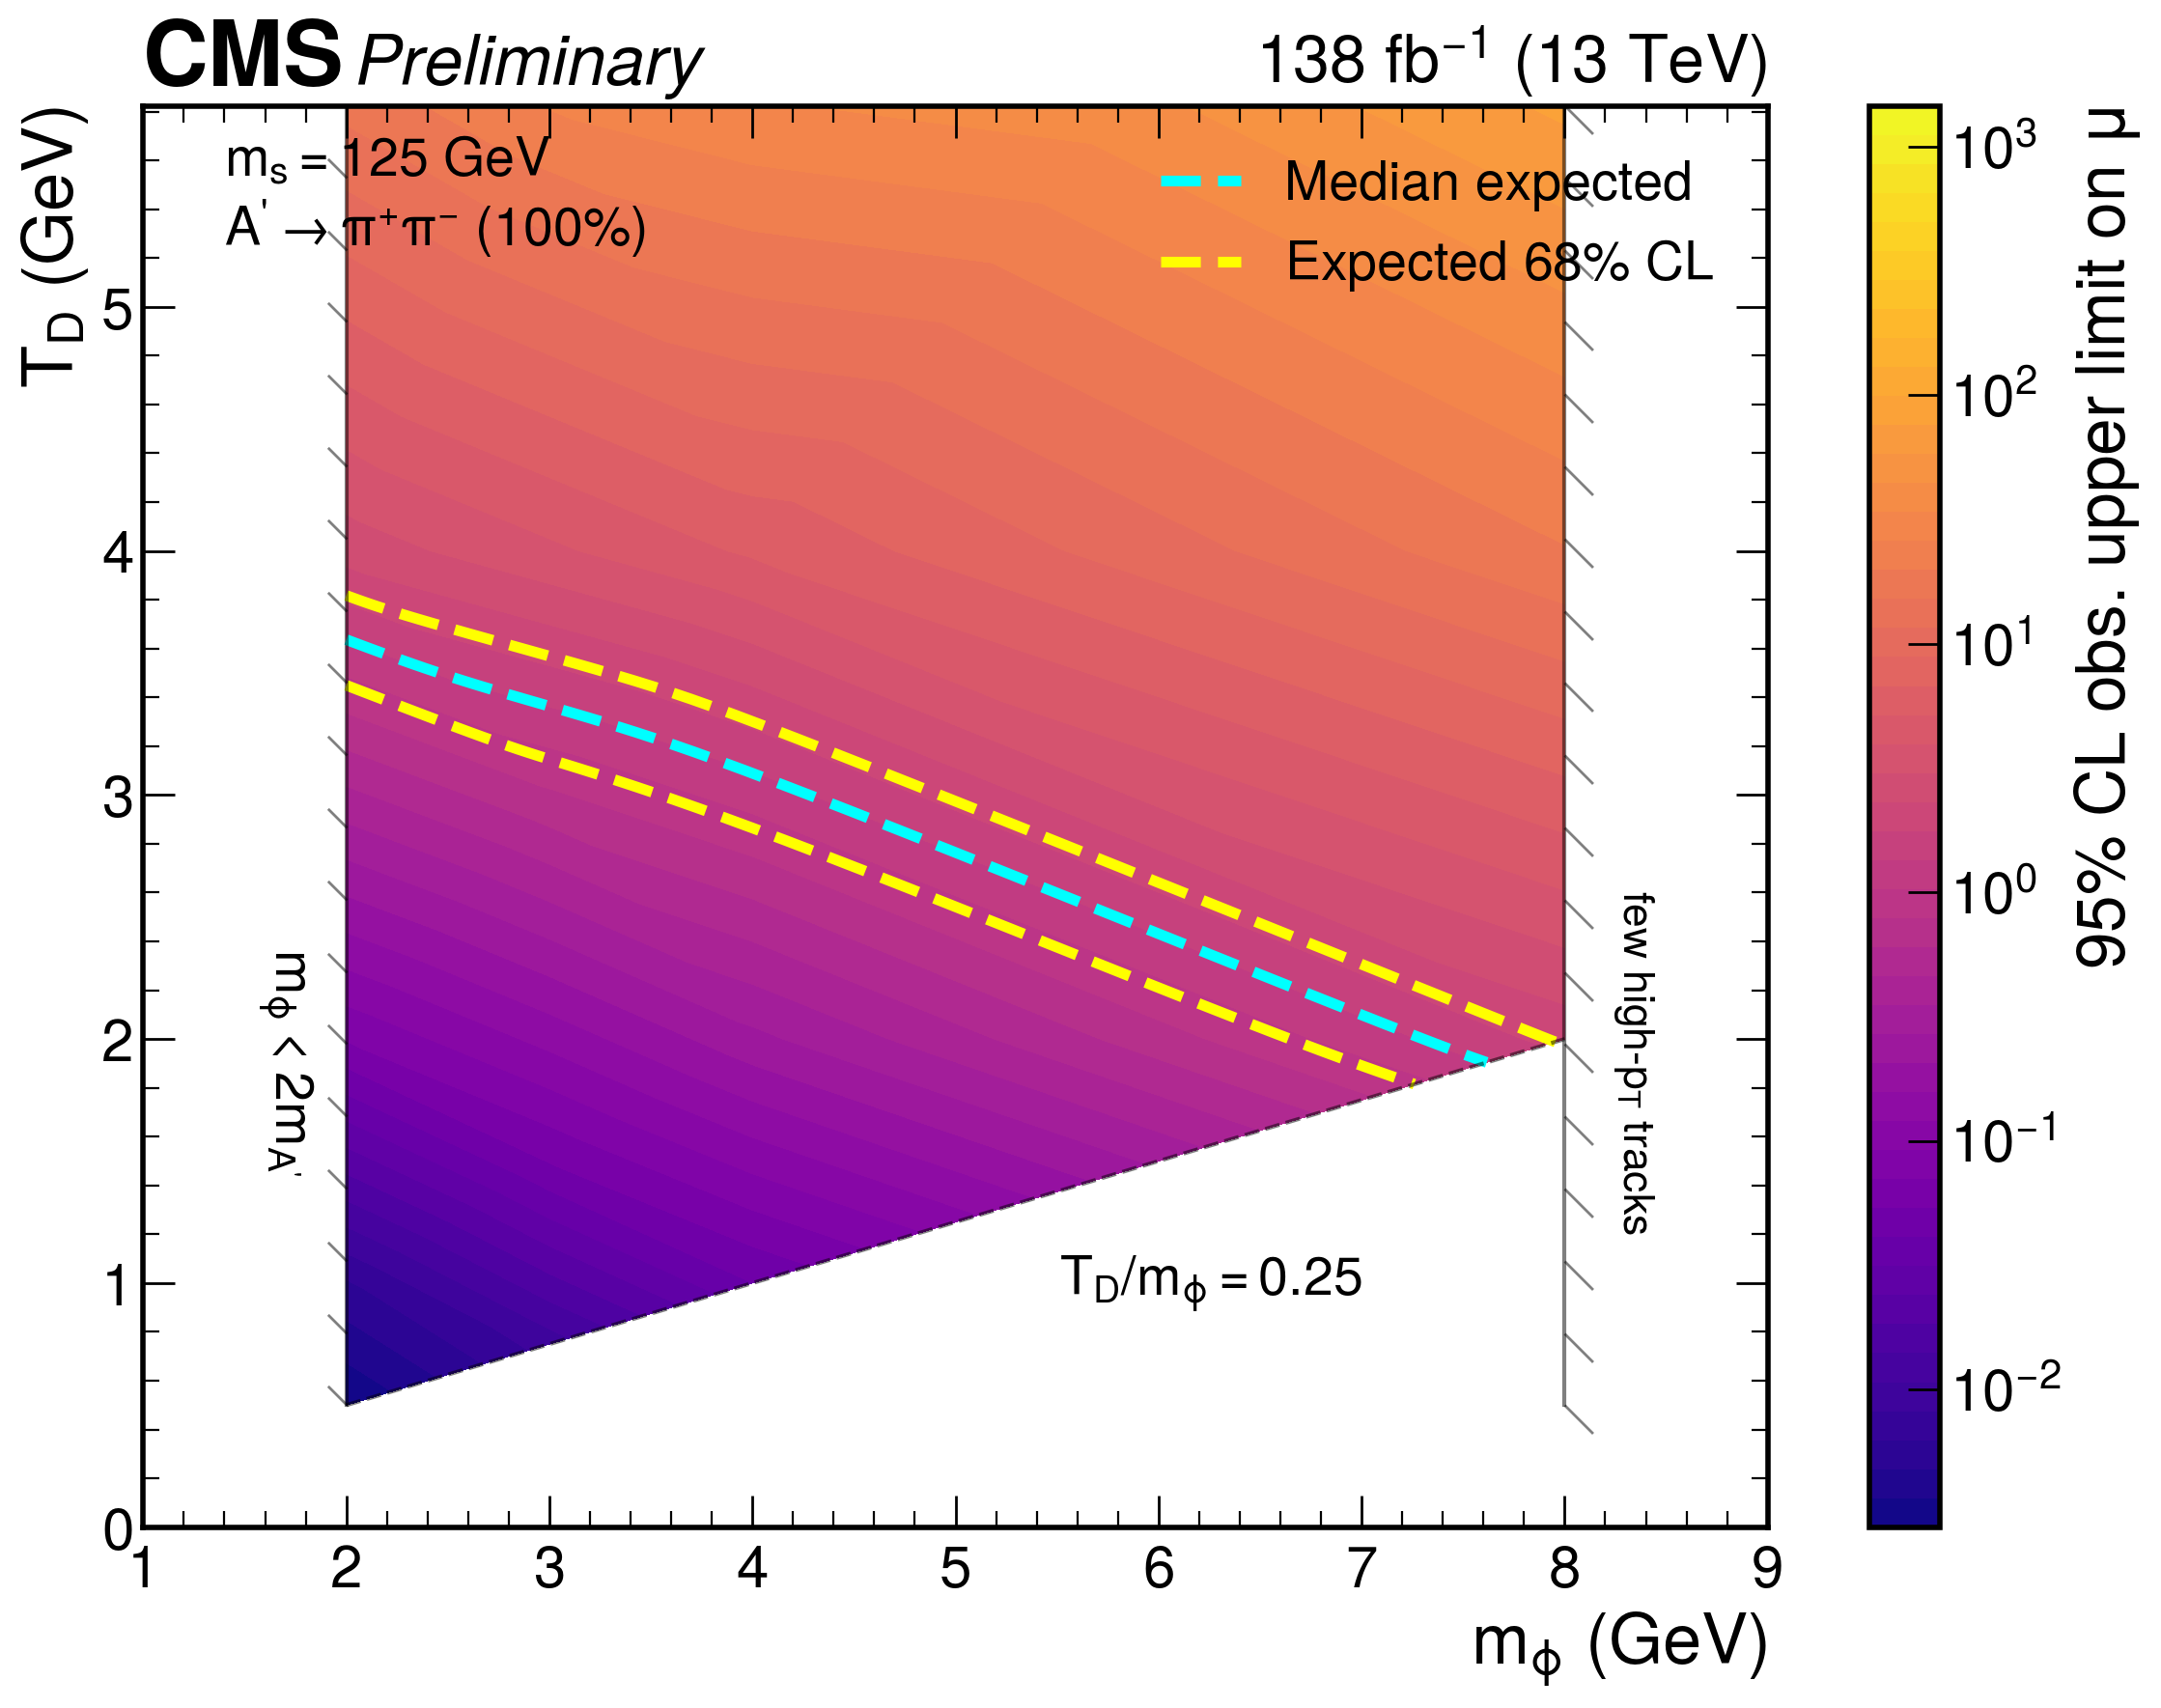

In [10]:
# example usage of the 2D limits function
fig = utils.plot_mPhi_temp_limits(
    ms=125, analysis='wh', decay='generic',
    path=itag, method='AsymptoticLimits',
    tricontour='log', showPoints=False, showObserved=False, showTheoryLines=True, cmsLabel=False, muLimit=True
)
_ = hep.cms.label(data=True, llabel='Preliminary', lumi=utils.lumis['combined'], ax=fig.get_axes()[0])
if saveToAN:
    fig.savefig(outDirAN + fig.get_label() + '.pdf', bbox_inches='tight')